# Interpreting models

### Which features the model uses, and why it said that about this row

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Why `feature_importances_` misleads you, how permutation importance fixes it and where it breaks on correlated columns, how to read partial dependence and ICE curves and what they assume, and how to build a local explanation for a single prediction from scratch |
| **You should already know** | [Random forests](../../04-ensembles/02-random-forest/), [linear regression](../../02-regression/01-linear-regression/), [ridge](../../02-regression/04-ridge-regression/), [overfitting](../../01-foundations/03-overfitting-and-underfitting/) |
| **Datasets** | California Housing |
| **Runtime** | Two to four minutes on a laptop CPU |
| **Next** | [12-03 Pipelines, and never leaking again](../03-pipelines/) |

---

## 1. The idea

A cross-validation score tells you that a model works. It tells you nothing
about *how*. Two different questions hide under the single word interpretability,
and mixing them up is where most of the confusion starts.

The **global** question is: across the whole dataset, which columns is this model
leaning on? That is what importance rankings and partial dependence answer.

The **local** question is: this one district got a prediction of 4.1, why that
number and not 2.0? That is what LIME and SHAP answer, one row at a time.

There is a third question people slip in without noticing, and nothing in this
notebook answers it: *what would happen if I changed the feature.* That is causal
inference. A fitted model has seen correlations in one dataset; it has no idea
what an intervention would do. When permutation importance says the model leans
hard on `MedInc`, the honest reading is "this model leans on this column", not
"income drives house prices".

I will build the tools in the order that they fail. The one scikit-learn hands
you for free is the one that lies the loudest, so it goes first.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

California Housing is the right dataset for this chapter because all eight
features mean something in plain English — median income, house age, average
occupancy, latitude and longitude. When a chart says the model bends on
`AveOccup` you can check that against what you know about California.

I subsample to 6,000 rows. Permutation importance and partial dependence both
re-predict the whole frame many times over, and 20,640 rows would turn a
two-minute notebook into a ten-minute one for no extra insight.

One quirk to keep in mind all the way through: the target is capped at 5.0
(that is $500,000, in units of $100k). Around a thousand districts in the full
data sit exactly on that cap, so every curve I draw flattens near the top for a
reason that has nothing to do with the model.

In [2]:
from sklearn.model_selection import train_test_split

X_all, y_all = datasets.california_housing()

keep = X_all.sample(6000, random_state=SEED).index
X_sub = X_all.loc[keep].reset_index(drop=True)
y_sub = y_all.loc[keep].reset_index(drop=True)

# Split once on row positions, so every model below sees exactly the same rows and
# their scores are comparable.
train_idx, test_idx = train_test_split(np.arange(len(X_sub)), test_size=0.25,
                                       random_state=SEED)

print(f"rows: {len(X_sub)}  ->  {len(train_idx)} train / {len(test_idx)} test")
print(f"features: {list(X_sub.columns)}")
print(f"target range: {y_sub.min():.2f} to {y_sub.max():.2f}   "
      f"({(y_sub >= 5.0).mean():.1%} of rows sit on the 5.0 cap)")

rows: 6000  ->  4500 train / 1500 test
features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
target range: 0.15 to 5.00   (4.8% of rows sit on the 5.0 cap)


## 2. Impurity importance and why it lies

Every tree-based model in scikit-learn exposes `feature_importances_`. For a
forest it is **mean decrease in impurity** (MDI): every time a feature is used
for a split, add up how much that split reduced the node's impurity, weighted by
how many training rows passed through the node, then average over trees and
normalise to sum to one.

It is free, because the numbers were computed during fitting anyway. It is also
biased in a specific and predictable direction: **a feature gets credit for
splits it was only able to make because it had a lot of candidate split points.**
A continuous column offers a tree hundreds of thresholds to try. A binary column
offers one. Given pure noise in both, the tree will reliably find a luckier split
in the continuous one.

Rather than assert that, I will plant the evidence. I add three columns that
contain nothing at all — no relationship with the target, none with each other,
none with the real features. They differ only in how many distinct values they
take.

| planted column | what it is | distinct values |
|---|---|---|
| `junk_coin` | a coin flip | 2 |
| `junk_id` | a random id, the kind that leaks into real feature tables | about 2,000 |
| `junk_normal` | a standard normal draw | one per row |

If MDI were honest, all three would sit at zero. If MDI is biased by cardinality,
they will separate in that order. Where they land relative to the eight real
features is a second and separate question, and the printed ranks answer it.

In [3]:
rng = np.random.default_rng(SEED)
n = len(X_sub)

X_junk = X_sub.copy()
X_junk["junk_coin"] = rng.integers(0, 2, n).astype(float)
X_junk["junk_id"] = rng.integers(0, 2000, n).astype(float)
X_junk["junk_normal"] = rng.normal(size=n)

JUNK = ["junk_coin", "junk_id", "junk_normal"]

for c in JUNK:
    print(f"{c:<12} {X_junk[c].nunique():>5} distinct values   "
          f"correlation with target: {np.corrcoef(X_junk[c], y_sub)[0, 1]:+.4f}")

junk_coin        2 distinct values   correlation with target: -0.0129
junk_id       1904 distinct values   correlation with target: -0.0032
junk_normal   6000 distinct values   correlation with target: -0.0102


The correlations confirm the columns are worthless. Now fit a forest that can
see them. I leave the trees unrestricted, which is the default and also the
condition under which the bias is worst: deep trees have plenty of small nodes
where a noise column can look useful.

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

X_junk_train, X_junk_test = X_junk.iloc[train_idx], X_junk.iloc[test_idx]
y_train, y_test = y_sub.iloc[train_idx], y_sub.iloc[test_idx]

forest_junk = RandomForestRegressor(n_estimators=150, random_state=SEED, n_jobs=-1)
forest_junk.fit(X_junk_train, y_train)

print(f"train R²: {forest_junk.score(X_junk_train, y_train):.4f}")
print(f"test  R²: {forest_junk.score(X_junk_test, y_test):.4f}")

train R²: 0.9672
test  R²: 0.7674


The gap between those two scores is the whole story in one line. The forest has
memorised a large part of the training set, and part of what it memorised is the
noise columns. MDI was computed on that training set.

**Permutation importance** asks a different question, and asks it on data the
model has not seen. Shuffle one column, breaking its link to the target while
leaving its marginal distribution alone, re-score, and record how much the score
fell. A column the model genuinely needs cannot be shuffled without hurting.
A column carrying nothing costs nothing to destroy.

I compute it twice, on train and on test, because the difference between those
two is a trap of its own.

In [5]:
perm_test = permutation_importance(forest_junk, X_junk_test, y_test,
                                   n_repeats=10, random_state=SEED, n_jobs=-1)
perm_train = permutation_importance(forest_junk, X_junk_train, y_train,
                                    n_repeats=10, random_state=SEED, n_jobs=-1)

cols = list(X_junk.columns)
mdi = forest_junk.feature_importances_

table = pd.DataFrame({
    "MDI": mdi,
    "perm (train)": perm_train.importances_mean,
    "perm (test)": perm_test.importances_mean,
}, index=cols).sort_values("MDI", ascending=False)

print(table.round(4).to_string())
print()
for c in JUNK:
    rank = list(table.index).index(c) + 1
    print(f"{c:<12} MDI rank {rank}/{len(cols)}   "
          f"MDI {table.loc[c, 'MDI']:.4f}   "
          f"perm(test) {table.loc[c, 'perm (test)']:+.4f}")

                MDI  perm (train)  perm (test)
MedInc       0.5111        0.9907       0.8022
AveOccup     0.1422        0.3144       0.1923
Latitude     0.0760        0.3476       0.2804
Longitude    0.0725        0.2464       0.2052
HouseAge     0.0564        0.1209       0.0588
AveRooms     0.0421        0.0654       0.0250
AveBedrms    0.0296        0.0342       0.0064
Population   0.0276        0.0277       0.0099
junk_normal  0.0214        0.0176      -0.0013
junk_id      0.0179        0.0138      -0.0012
junk_coin    0.0031        0.0030      -0.0013

junk_coin    MDI rank 11/11   MDI 0.0031   perm(test) -0.0013
junk_id      MDI rank 10/11   MDI 0.0179   perm(test) -0.0012
junk_normal  MDI rank 9/11   MDI 0.0214   perm(test) -0.0013


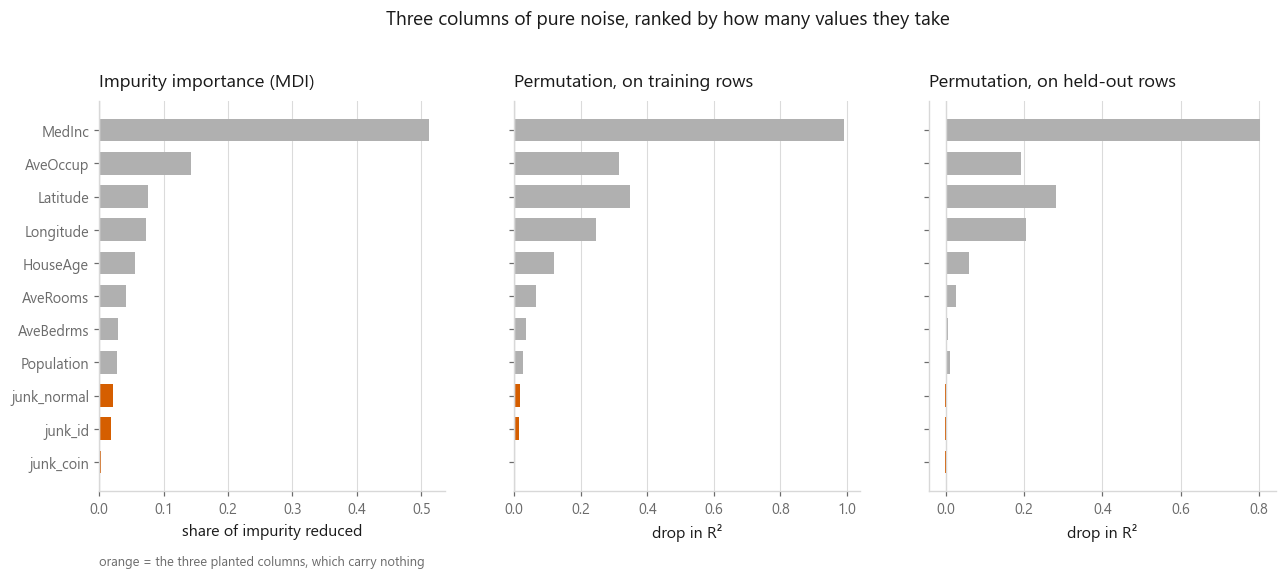

In [6]:
order = np.argsort(mdi)                      # ascending, so barh puts the biggest on top
names = [cols[i] for i in order]
colours = [style.HIGHLIGHT if c in JUNK else style.NEUTRAL for c in names]

panels = [
    ("Impurity importance (MDI)", mdi[order], "share of impurity reduced"),
    ("Permutation, on training rows", perm_train.importances_mean[order], "drop in R²"),
    ("Permutation, on held-out rows", perm_test.importances_mean[order], "drop in R²"),
]

fig, axes = plt.subplots(1, 3, figsize=(13.8, 4.6), sharey=True)
for ax, (headline, values, xlabel) in zip(axes, panels):
    ax.barh(names, values, color=colours, height=0.68)
    ax.axvline(0, color=style.RULE, lw=0.9)
    ax.set_xlabel(xlabel)
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", visible=True)
    style.title(ax, headline)

fig.suptitle("Three columns of pure noise, ranked by how many values they take",
             x=0.5, y=1.06, fontsize=12.5, color=style.INK)
style.note(axes[0], "orange = the three planted columns, which carry nothing")
style.save(fig, FIG / "fig-01-impurity-vs-permutation.png")

Read the left panel for spread rather than for rank, and read the printed ranks
before you read anything into the picture. All three planted columns finished at
the bottom of the MDI ordering, below every real feature. MDI did not invert the
ranking here, and I am not going to claim it did.

What it did do is the bias, and the bias is in two places in that panel.

First, the three orange bars are different heights, and they are ordered by
cardinality. Every one of those columns contains nothing — no link to the target,
none to each other, none to the real features — so the correct score for all three
is zero and the correct spread between them is zero. Instead the coin flip barely
registers while the id column and the normal draw collect a visible share, and the
only thing separating them is how many thresholds each one offered the tree. That
spread is manufactured entirely by cardinality.

Second, look at where the continuous noise column lands against the weakest real
features in the printed table. A column straight out of a random number generator
is being credited with a substantial fraction of what a genuine measurement got.

So the failure is quieter than an inverted ranking and more common than one: MDI
puts a number greater than zero next to columns that deserve exactly zero, and it
sizes those numbers by how many split points the column offered rather than by how
much the column knows.

The middle panel is the trap I mentioned. Permutation importance measured on the
training set inherits the same problem for a different reason — the forest really
did use those noise columns to memorise training rows, so shuffling them really
does hurt the training score. Permutation importance is only honest on data the
model has not seen.

The right panel is the one to trust, and it is the clean result of this section.
The planted columns collapse to roughly zero, and some land slightly negative,
which happens when shuffling a useless column accidentally helps. Negative
permutation importance is normal noise around zero, not a signal. Compare that
against the left panel: same model, same columns, and the credit MDI gave them is
gone the moment the question is asked on data the model has not seen.

Two practical consequences. First, an id column that sneaks into your feature
table collects MDI credit it cannot possibly have earned, and how much it collects
depends on how many distinct values it happens to take rather than on anything
about your problem. Second, if you are ranking a mix of continuous features and
one-hot dummies, MDI is systematically unfair to the dummies before it has seen a
single row.

## 3. Permutation importance and its correlated-features trap

Permutation importance has its own failure, and it is worse than MDI's because
it is silent. It reports *near zero* for features that matter.

Here is the mechanism. Permuting one column asks: how much worse does the model
get when this column becomes unavailable? If a second column carries nearly the
same information, the model does not become worse at all — it reads the answer
off the twin. Do the same for the twin, and the model reads it off the original.
Each is individually disposable. Together they are indispensable. The procedure
only ever asks about them one at a time, so it never finds out.

I will build the twin deliberately: `MedInc` plus a whisper of noise.

In [7]:
X_twin = X_sub.copy()
X_twin["MedInc_twin"] = X_sub["MedInc"] + rng.normal(
    0, 0.01 * X_sub["MedInc"].std(), n)

X_twin_train, X_twin_test = X_twin.iloc[train_idx], X_twin.iloc[test_idx]

forest_twin = RandomForestRegressor(n_estimators=150, random_state=SEED, n_jobs=-1)
forest_twin.fit(X_twin_train, y_train)

# The reference model: same rows, same settings, no twin.
forest_clean = RandomForestRegressor(n_estimators=150, random_state=SEED, n_jobs=-1)
forest_clean.fit(X_sub.iloc[train_idx], y_train)

print(f"correlation MedInc vs MedInc_twin: "
      f"{X_twin['MedInc'].corr(X_twin['MedInc_twin']):.5f}")
print(f"test R² without the twin: {forest_clean.score(X_sub.iloc[test_idx], y_test):.4f}")
print(f"test R² with the twin   : {forest_twin.score(X_twin_test, y_test):.4f}")

correlation MedInc vs MedInc_twin: 0.99995
test R² without the twin: 0.7794
test R² with the twin   : 0.7789


The two models score about the same, as they must — the twin adds no information.
Now look at what happens to the importance of income.

The fix is **grouped permutation**: shuffle the whole correlated block at once,
using the *same* row order for every column in the block so their joint structure
survives intact. Then the question becomes "how much worse is the model without
any of this information", which is the question you meant to ask.

scikit-learn does not ship this, so it is a dozen lines.

In [8]:
def permute_group(model, X, y, group, n_repeats=10, seed=SEED):
    """Score drop when `group` is shuffled as a block.

    The single shared `order` is the whole point: applying one permutation to
    every column keeps the block's internal correlations exactly as they were,
    and breaks only its link to the target and to the columns outside the block.
    """
    rng_local = np.random.default_rng(seed)
    base = model.score(X, y)
    drops = []
    for _ in range(n_repeats):
        order = rng_local.permutation(len(X))
        X_shuffled = X.copy()
        for c in group:
            X_shuffled[c] = X[c].to_numpy()[order]
        drops.append(base - model.score(X_shuffled, y))
    return float(np.mean(drops)), float(np.std(drops))


perm_twin = permutation_importance(forest_twin, X_twin_test, y_test, n_repeats=10,
                                   random_state=SEED, n_jobs=-1)
twin_cols = list(X_twin.columns)

# Sanity check: on a group of one, this must agree with scikit-learn.
mine, _ = permute_group(forest_twin, X_twin_test, y_test, ["HouseAge"])
print(f"HouseAge, mine        : {mine:.4f}")
print(f"HouseAge, scikit-learn: {perm_twin.importances_mean[twin_cols.index('HouseAge')]:.4f}")
print("(different shuffles, so they agree to within the noise of shuffling)")

HouseAge, mine        : 0.0588
HouseAge, scikit-learn: 0.0603
(different shuffles, so they agree to within the noise of shuffling)


In [9]:
perm_clean = permutation_importance(forest_clean, X_sub.iloc[test_idx], y_test,
                                    n_repeats=10, random_state=SEED, n_jobs=-1)

alone_medinc = perm_twin.importances_mean[twin_cols.index("MedInc")]
alone_twin = perm_twin.importances_mean[twin_cols.index("MedInc_twin")]
solo_reference = perm_clean.importances_mean[list(X_sub.columns).index("MedInc")]
together, together_sd = permute_group(forest_twin, X_twin_test, y_test,
                                      ["MedInc", "MedInc_twin"])

print(f"MedInc, no twin in the model : {solo_reference:.4f}")
print(f"MedInc alone, twin present   : {alone_medinc:.4f}")
print(f"MedInc_twin alone            : {alone_twin:.4f}")
print(f"both shuffled together       : {together:.4f}  (sd {together_sd:.4f})")
print(f"\nsum of the two individual scores: {alone_medinc + alone_twin:.4f}"
      f"   vs grouped: {together:.4f}")

MedInc, no twin in the model : 0.7956
MedInc alone, twin present   : 0.2502
MedInc_twin alone            : 0.1930
both shuffled together       : 0.7990  (sd 0.0153)

sum of the two individual scores: 0.4432   vs grouped: 0.7990


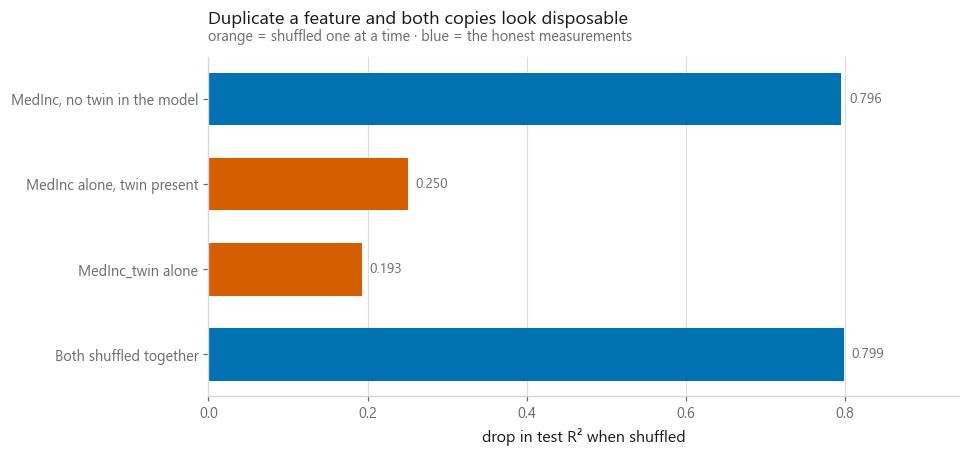

In [10]:
labels = [
    "Both shuffled together",
    "MedInc_twin alone",
    "MedInc alone, twin present",
    "MedInc, no twin in the model",
]
values = [together, alone_twin, alone_medinc, solo_reference]
colours = [style.PALETTE[0], style.HIGHLIGHT, style.HIGHLIGHT, style.PALETTE[0]]

fig, ax = plt.subplots(figsize=(8.8, 4.0))
ax.barh(labels, values, color=colours, height=0.62)
span = max(values) - min(0.0, min(values))
for i, v in enumerate(values):
    ax.text(v + span * 0.012, i, f"{v:.3f}", va="center",
            fontsize=9, color=style.MUTED)
ax.set_xlim(min(0.0, min(values) * 1.2), max(values) * 1.18)
ax.set_xlabel("drop in test R² when shuffled")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
style.title(ax, "Duplicate a feature and both copies look disposable",
            "orange = shuffled one at a time · blue = the honest measurements")
style.save(fig, FIG / "fig-02-correlated-trap.png")

The top and bottom bars are the same quantity measured two ways, and they match:
income is worth what it was always worth. The two orange bars in the middle are
the lie. Nothing about the model changed, nothing about the data changed, and the
most useful feature in the dataset now reports as minor — twice.

I used a near-perfect twin to make the effect unmissable, but you do not need
one. Correlations well short of 1.0 deflate both partners noticeably, and real
feature tables are full of them: total and average of the same thing, a raw value
and its log, this month and last month.

What to do about it, in order of effort:

1. Cluster the features by correlation, cut the tree at some threshold, and
   permute each cluster as a block. `scipy.cluster.hierarchy` on a Spearman
   distance matrix is the standard recipe.
2. Drop one of each near-duplicate pair before you measure anything.
3. Read a near-zero permutation importance as "either useless, or duplicated",
   and check the correlation matrix before believing the first reading.

The same warning applies to everything in the rest of this notebook. Permutation
importance, partial dependence and LIME all work by moving one feature while
holding the others still, and they all get less trustworthy as the features get
more correlated.

## 4. Partial dependence and ICE

Importance tells you *how much* a feature matters. It says nothing about *which
way*. Partial dependence answers the shape question.

The definition is short. For a feature $j$ and a value $v$, the partial
dependence is

$$\text{PD}_j(v) = \frac{1}{n}\sum_{i=1}^{n} f\!\left(x^{(i)} \text{ with } x_j = v\right)$$

Take every row, force feature $j$ to $v$, leave every other column as it is,
predict, average. Repeat over a grid of $v$. It is the model's average response
to that feature, with everything else marginalised out.

That averaging step is where the assumption hides, and it is a strong one. The
formula asks the model to predict for rows that were built by combination, not
observed. Setting `AveRooms = 10` on a dense city district produces a district
that does not exist in California, and the model has never seen anything like it,
so its answer there is extrapolation. **Partial dependence is trustworthy to the
degree that the feature is independent of the others.** When it is not, ALE plots
(accumulated local effects) do the same job using only local, realistic
neighbourhoods.

One implementation note. For tree ensembles scikit-learn defaults to
`method="recursion"`, which walks the trees and is far faster, but it computes
the average over the training distribution baked into the tree weights rather
than over the data you pass. I use `method="brute"`, which is the definition
above, executed literally.

MedInc     partial dependence runs from 1.36 to 3.59   (swing 2.23)
AveOccup   partial dependence runs from 1.79 to 2.81   (swing 1.03)
HouseAge   partial dependence runs from 1.95 to 2.26   (swing 0.31)


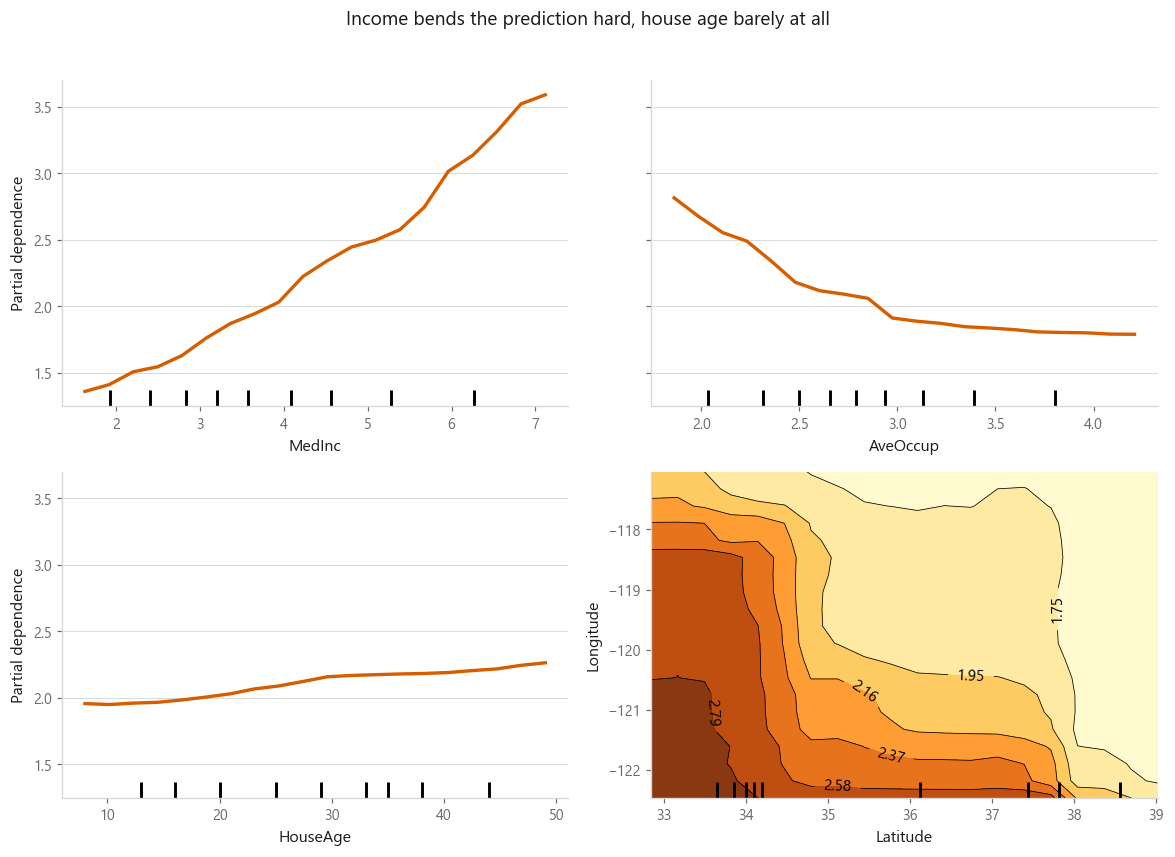

In [11]:
from sklearn.inspection import PartialDependenceDisplay

# Brute-force partial dependence re-predicts n_background x grid_resolution rows per
# feature, so the background set is where the runtime lives. 600 rows is plenty for
# an average.
X_pd = X_sub.iloc[train_idx].sample(600, random_state=SEED)

fig, axes = plt.subplots(2, 2, figsize=(10.8, 7.6))
disp = PartialDependenceDisplay.from_estimator(
    forest_clean, X_pd,
    features=["MedInc", "AveOccup", "HouseAge", ("Latitude", "Longitude")],
    method="brute", grid_resolution=20, n_jobs=-1, ax=axes,
    line_kw={"color": style.HIGHLIGHT, "lw": 2.2},
    contour_kw={"cmap": "YlOrBr", "alpha": 0.95},
)
fig.suptitle("Income bends the prediction hard, house age barely at all",
             x=0.5, y=1.02, fontsize=12.5, color=style.INK)
fig.tight_layout()
style.save(fig, FIG / "fig-03-partial-dependence.png")

for name, result in zip(["MedInc", "AveOccup", "HouseAge"], disp.pd_results[:3]):
    average = np.asarray(result["average"])[0]
    print(f"{name:<10} partial dependence runs from {average.min():.2f} to "
          f"{average.max():.2f}   (swing {average.max() - average.min():.2f})")

The swings printed above are the numbers to compare: a feature whose partial
dependence is flat cannot be moving predictions much, whatever any importance
chart says.

The income curve rises and then flattens near the top. Some of that flattening is
the model; some of it is the 5.0 cap in the target, which no model can predict
past. The occupancy curve falls steeply over its first stretch and then stops
caring, which is the shape you get when a feature separates one small extreme
group from everyone else.

The latitude-longitude panel is a two-way partial dependence, and it is a map.
The model has rediscovered the California coastline from two unlabelled numeric
columns, because that is where the expensive districts are. Two-way plots are the
cheapest way to see an interaction, and also the most expensive to compute — the
grid is quadratic.

### What the average hides

Partial dependence is a mean, and a mean can describe nobody. If income raises
the prediction for coastal districts and lowers it for inland ones, the average
of those two curves is flat and the plot says "no effect".

**ICE curves** (individual conditional expectation) are the same computation with
the averaging step removed: one line per row. Centering each line at its left
edge makes the comparison about shape rather than starting height.

MedInc     total change across the grid, per district: 10th pct +1.71, median +2.23, 90th pct +2.76
AveOccup   total change across the grid, per district: 10th pct -1.89, median -0.96, 90th pct -0.35


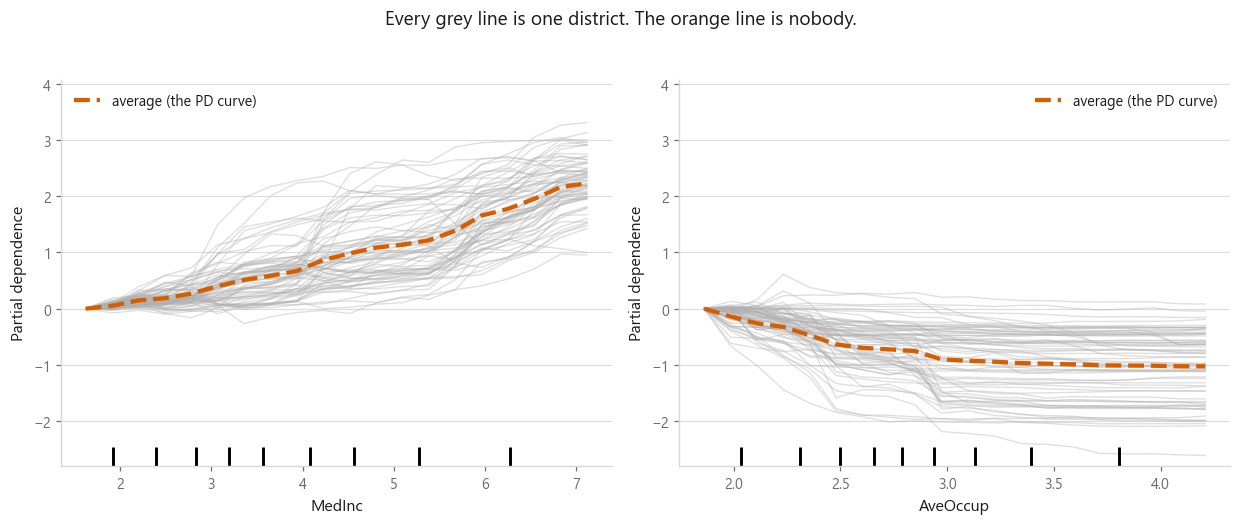

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.6))
disp_ice = PartialDependenceDisplay.from_estimator(
    forest_clean, X_pd, features=["MedInc", "AveOccup"],
    kind="both", centered=True, subsample=70, random_state=SEED,
    grid_resolution=20, n_jobs=-1, ax=axes,
    ice_lines_kw={"color": style.NEUTRAL, "alpha": 0.40, "lw": 0.9},
    pd_line_kw={"color": style.HIGHLIGHT, "lw": 2.8, "label": "average (the PD curve)"},
)
axes[0].legend(loc="upper left")
fig.suptitle("Every grey line is one district. The orange line is nobody.",
             x=0.5, y=1.03, fontsize=12.5, color=style.INK)
fig.tight_layout()
style.save(fig, FIG / "fig-04-ice-curves.png")

for name, result in zip(["MedInc", "AveOccup"], disp_ice.pd_results):
    curves = np.asarray(result["individual"])[0]      # (n_rows, n_grid)
    centred = curves - curves[:, [0]]
    lo, hi = np.percentile(centred[:, -1], [10, 90])
    print(f"{name:<10} total change across the grid, per district: "
          f"10th pct {lo:+.2f}, median {np.median(centred[:, -1]):+.2f}, 90th pct {hi:+.2f}")

The printed percentiles are the point. If every district responded the same way,
the 10th and 90th percentiles would sit on top of each other. The wider that
range, the more the single averaged curve is hiding, and the width itself is a
measure of how much this feature interacts with the others.

My habit now is to draw ICE first and the average second. If the grey lines are
parallel, the average summarises them fairly and I can use partial dependence
with a clear conscience. If they fan out or cross, the average is a fiction and I
go looking for the feature it is interacting with.

## 5. Explaining one prediction with a local surrogate

Everything so far has been global. Now the local question: this district, this
prediction, why?

**LIME** — local interpretable model-agnostic explanations — has a simple idea
behind the acronym. A complicated function is still roughly linear if you look at
a small enough patch of it. So: generate points around the instance you care
about, ask the black box what it predicts at each one, weight the points by how
close they are to your instance, and fit a plain weighted linear regression to
those answers. The coefficients of that little linear model are the explanation.

The `lime` package is not installed here, and that turns out to be a gift,
because the method is about fifteen lines and writing them makes every arbitrary
choice inside it visible.

Three decisions have to be made, and none of them has a principled answer:

| decision | what I do | why it is arbitrary |
|---|---|---|
| where to sample | draw from the global feature distribution, $N(\mu, \sigma)$ per column | independent draws produce districts that cannot exist |
| how to weight | $w = \exp(-d^2 / \text{width}^2)$ on standardised distance | the width sets what "local" means, and nothing sets the width |
| what to fit | ridge on the standardised features | a linear model is only a good local approximation if the patch is small |

In [13]:
from sklearn.linear_model import Ridge


def local_surrogate(model, x0, background, n_samples=5000, kernel_width=None,
                    seed=SEED):
    """A LIME-style local explanation for one row, from scratch.

    Returns the contribution of each feature to this prediction, where a
    contribution is the surrogate's coefficient times the instance's standardised
    feature value, so the contributions plus the intercept reproduce the
    surrogate's own prediction exactly.
    """
    rng_local = np.random.default_rng(seed)
    mu = background.to_numpy().mean(axis=0)
    sd = background.to_numpy().std(axis=0)
    d = len(mu)
    if kernel_width is None:
        kernel_width = 0.75 * np.sqrt(d)          # the default the lime package uses

    z = rng_local.normal(size=(n_samples, d))     # standardised space
    z[0] = (x0.to_numpy() - mu) / sd              # keep the instance itself in the sample
    Z = pd.DataFrame(z * sd + mu, columns=background.columns)

    answers = model.predict(Z)                    # the only thing we ask the black box
    distance = np.linalg.norm(z - z[0], axis=1)
    weight = np.exp(-(distance ** 2) / kernel_width ** 2)

    surrogate = Ridge(alpha=1.0).fit(z, answers, sample_weight=weight)
    contribution = surrogate.coef_ * z[0]

    return {
        "contribution": pd.Series(contribution, index=background.columns),
        "intercept": float(surrogate.intercept_),
        "local_pred": float(surrogate.intercept_ + contribution.sum()),
        "fit": float(surrogate.score(z, answers, sample_weight=weight)),
        # How many samples actually carry the fit, after the kernel is applied.
        "effective_n": float(weight.sum() ** 2 / (weight ** 2).sum()),
    }


X_train_clean = X_sub.iloc[train_idx]
X_test_clean = X_sub.iloc[test_idx]
predictions = forest_clean.predict(X_test_clean)

# One expensive district and one cheap one, taken a little in from the extremes so
# neither is sitting on the 5.0 cap.
hi = int(np.argsort(predictions)[-40])
lo = int(np.argsort(predictions)[40])

explanations = {}
for label, pos in [("expensive district", hi), ("cheap district", lo)]:
    x0 = X_test_clean.iloc[pos]
    result = local_surrogate(forest_clean, x0, X_train_clean)
    result["x0"] = x0
    result["model_pred"] = float(predictions[pos])
    explanations[label] = result

    print(f"--- {label} ---")
    print(f"forest predicts   : {result['model_pred']:.3f}")
    print(f"surrogate predicts: {result['local_pred']:.3f}")
    print(f"local intercept   : {result['intercept']:.3f}   "
          f"(the surrogate's value at the average district)")
    print(f"weighted R² of the surrogate: {result['fit']:.3f}   "
          f"effective samples: {result['effective_n']:.0f} of 5000")
    print(result["contribution"].sort_values(key=abs, ascending=False).round(3).to_string())
    print()

--- expensive district ---
forest predicts   : 4.566
surrogate predicts: 3.577
local intercept   : 2.458   (the surrogate's value at the average district)
weighted R² of the surrogate: 0.671   effective samples: 2535 of 5000
MedInc        1.036
Latitude      0.146
Longitude    -0.094
AveRooms      0.037
Population   -0.030
AveOccup      0.025
AveBedrms    -0.004
HouseAge      0.004

--- cheap district ---
forest predicts   : 0.710
surrogate predicts: 1.482
local intercept   : 2.442   (the surrogate's value at the average district)
weighted R² of the surrogate: 0.625   effective samples: 2276 of 5000
MedInc       -0.701
Latitude     -0.492
Longitude     0.228
Population   -0.012
AveBedrms     0.009
AveRooms      0.008
AveOccup      0.008
HouseAge     -0.007



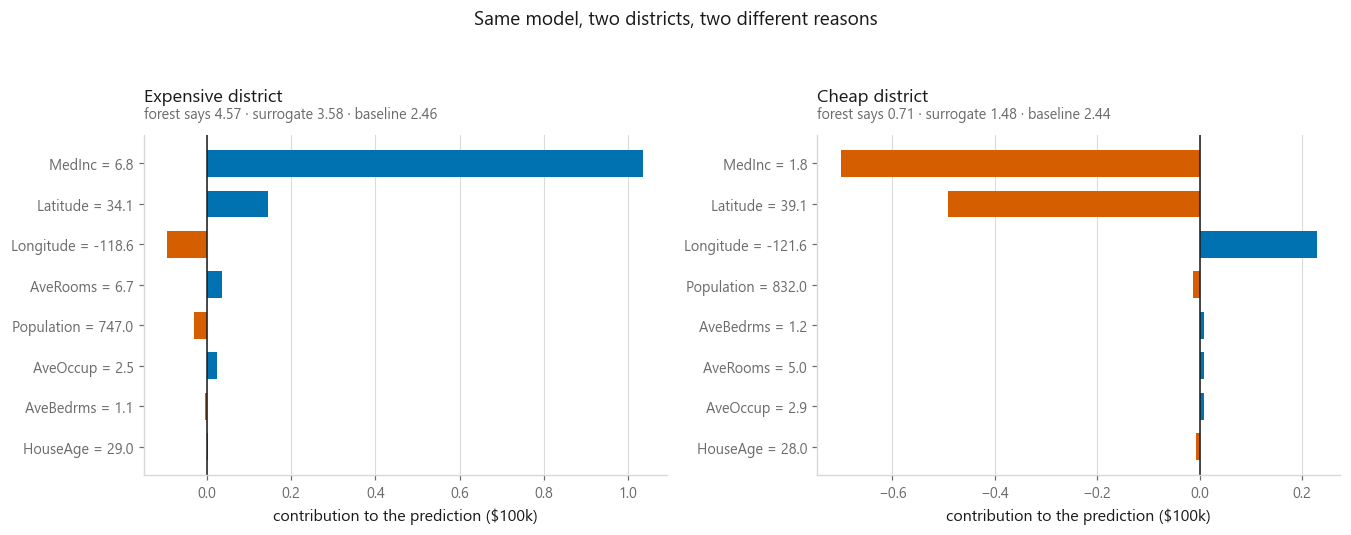

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.6))
for ax, (label, result) in zip(axes, explanations.items()):
    contribution = result["contribution"].sort_values(key=abs)
    ticks = [f"{c} = {result['x0'][c]:,.1f}" for c in contribution.index]
    bar_colours = [style.PALETTE[0] if v > 0 else style.HIGHLIGHT
                   for v in contribution.to_numpy()]
    ax.barh(ticks, contribution.to_numpy(), color=bar_colours, height=0.66)
    ax.axvline(0, color=style.INK, lw=1.0)
    ax.set_xlabel("contribution to the prediction ($100k)")
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", visible=True)
    style.title(ax, label.capitalize(),
                f"forest says {result['model_pred']:.2f} · "
                f"surrogate {result['local_pred']:.2f} · "
                f"baseline {result['intercept']:.2f}")

fig.suptitle("Same model, two districts, two different reasons",
             x=0.5, y=1.05, fontsize=12.5, color=style.INK)
fig.tight_layout()
style.save(fig, FIG / "fig-05-local-surrogate.png")

Each bar reads as "this feature moved the prediction this far from the local
baseline", and the bars plus the baseline reproduce the surrogate's number
exactly. Blue pushes up, orange pushes down.

Now the caveats, because a plot this persuasive deserves them.

The **weighted R²** printed above says how well a straight line described the
model in that neighbourhood. If it is low, the explanation is describing a patch
the model does not actually behave linearly on, and the bars mean much less than
they look like they mean. LIME's own output shows this number; most screenshots
of LIME crop it out.

The **effective sample count** is the second warning. Sampling 5,000 points and
then down-weighting the far ones means the fit rests on a fraction of them.

And the samples themselves are dubious. Drawing each column independently from
its own normal produces districts with negative population, latitudes in the
ocean, ten-room apartments with six occupants. The model answers anyway, and the
surrogate fits those answers. Clipping to observed ranges helps a little;
sampling from a joint model of the features helps more, and is no longer simple.

The third caveat is the one that ends arguments: the explanation depends on
choices you made, not only on the model.

In [15]:
seed_a = local_surrogate(forest_clean, X_test_clean.iloc[hi], X_train_clean, seed=1)
seed_b = local_surrogate(forest_clean, X_test_clean.iloc[hi], X_train_clean, seed=2)
narrow = local_surrogate(forest_clean, X_test_clean.iloc[hi], X_train_clean,
                         kernel_width=0.6)
wide = local_surrogate(forest_clean, X_test_clean.iloc[hi], X_train_clean,
                       kernel_width=12.0)

comparison = pd.DataFrame({
    "seed 1": seed_a["contribution"],
    "seed 2": seed_b["contribution"],
    "narrow kernel (0.6)": narrow["contribution"],
    "wide kernel (12.0)": wide["contribution"],
}).round(3)
print(comparison.to_string())
print()
print(f"largest change between two random seeds : "
      f"{(seed_a['contribution'] - seed_b['contribution']).abs().max():.3f}")
print(f"largest change between the two kernels  : "
      f"{(narrow['contribution'] - wide['contribution']).abs().max():.3f}")
print(f"surrogate fit, narrow kernel: {narrow['fit']:.3f} "
      f"(effective samples {narrow['effective_n']:.0f})")
print(f"surrogate fit, wide kernel  : {wide['fit']:.3f} "
      f"(effective samples {wide['effective_n']:.0f})")

            seed 1  seed 2  narrow kernel (0.6)  wide kernel (12.0)
MedInc       1.068   1.058                0.155               0.897
HouseAge     0.004   0.004                0.000               0.002
AveRooms     0.031   0.033                0.057               0.001
AveBedrms   -0.004  -0.004               -0.003              -0.002
Population  -0.028  -0.029                0.043              -0.015
AveOccup     0.026   0.026                0.006               0.017
Latitude     0.167   0.159               -0.036               0.164
Longitude   -0.098  -0.091               -0.035              -0.103

largest change between two random seeds : 0.010
largest change between the two kernels  : 0.743
surrogate fit, narrow kernel: 0.139 (effective samples 3)
surrogate fit, wide kernel  : 0.642 (effective samples 4992)


Two things to notice in that table. Re-running with a different random seed moves
the numbers, which is why the same instance can get different explanations on
consecutive runs — a known and much-complained-about property of LIME. And
widening the kernel until "local" means "everywhere" turns the explanation into
an ordinary global linear fit, which is exactly what you would expect and exactly
why the width matters.

### What SHAP adds

SHAP starts from a different place, and it is the reason it has largely displaced
LIME. Instead of approximating the model near a point, it asks a fair-division
question borrowed from cooperative game theory: the prediction is a payout, the
features are players who cooperated to produce it, so how should the payout be
split?

Shapley's answer, from 1953, is the average marginal contribution of a player
over every order in which the players could have joined:

$$\phi_i = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|!\,(d - |S| - 1)!}{d!}
\left[v(S \cup \{i\}) - v(S)\right]$$

where $v(S)$ is the model's expected prediction when only the features in $S$ are
known and the rest are drawn from a background set. It is the unique split
satisfying a short list of fairness properties, and one of them is what makes it
useful here: **local accuracy**, meaning the attributions and the baseline add up
to the actual prediction. Not approximately. Exactly.

LIME has no such guarantee — its bars add up to whatever the little linear model
happened to say.

The catch is the sum: $2^d$ subsets. The `shap` package exists because getting
this to run on real feature counts needs approximation (KernelSHAP) or a
structure-specific trick (TreeSHAP, which is exact for trees and polynomial). It
is not installed here, and it does not need to be, because $2^8 = 256$ and eight
features is small enough to just do the sum.

In [16]:
import itertools
from math import factorial

d = X_train_clean.shape[1]
feature_names = list(X_train_clean.columns)
background = X_train_clean.sample(60, random_state=SEED).to_numpy()
x0 = X_test_clean.iloc[hi].to_numpy()

subsets = [frozenset(s) for r in range(d + 1)
           for s in itertools.combinations(range(d), r)]

# For each subset: take the known features from the instance, the rest from the
# background rows, and average the predictions. One stacked predict call.
blocks = []
for S in subsets:
    block = background.copy()
    if S:
        idx = list(S)
        block[:, idx] = x0[idx]
    blocks.append(block)

values = forest_clean.predict(
    pd.DataFrame(np.vstack(blocks), columns=feature_names)
).reshape(len(subsets), len(background)).mean(axis=1)
v = dict(zip(subsets, values))

phi = np.zeros(d)
for i in range(d):
    for S in subsets:
        if i in S:
            continue
        k = len(S)
        weight = factorial(k) * factorial(d - k - 1) / factorial(d)
        phi[i] += weight * (v[S | {i}] - v[S])

baseline = v[frozenset()]
shapley = pd.Series(phi, index=feature_names)

print(f"baseline (average prediction over the background): {baseline:.4f}")
print(f"baseline + sum of Shapley values                 : {baseline + phi.sum():.4f}")
print(f"the forest's actual prediction                   : {forest_clean.predict(X_test_clean.iloc[[hi]])[0]:.4f}")
print(f"gap                                              : "
      f"{abs(baseline + phi.sum() - forest_clean.predict(X_test_clean.iloc[[hi]])[0]):.2e}")
print()
print(pd.DataFrame({
    "Shapley (exact)": shapley,
    "local surrogate": explanations["expensive district"]["contribution"],
}).sort_values("Shapley (exact)", key=abs, ascending=False).round(3).to_string())

baseline (average prediction over the background): 1.8762
baseline + sum of Shapley values                 : 4.5656
the forest's actual prediction                   : 4.5656


gap                                              : 1.78e-15

            Shapley (exact)  local surrogate
MedInc                1.662            1.036
AveOccup              0.368            0.025
Latitude              0.314            0.146
HouseAge              0.123            0.004
Longitude             0.106           -0.094
AveRooms              0.096            0.037
AveBedrms             0.044           -0.004
Population           -0.025           -0.030


The gap printed above is the local accuracy property, verified rather than
asserted: the baseline plus the eight attributions equal the prediction to
floating-point precision. Nothing in the LIME construction gives you that.

The side-by-side comparison is worth staring at. The two methods usually agree on
which features dominate and disagree on the exact amounts, which is roughly the
right expectation — they are answering related but different questions, one about
fair credit assignment and one about a local linear fit.

Two honest caveats on Shapley values, since they are usually sold without any.
The subsets sum is over $2^d$ terms, so eight features is 256 and thirty features
is a billion, hence the approximations. And the $v(S)$ I used replaces unknown
features with values from a background set drawn independently, which means it
evaluates the model on impossible rows for exactly the same reason partial
dependence does. Correlated features remain the unsolved problem in every method
in this notebook.

## Cheat sheet

| | |
|---|---|
| **`feature_importances_` (MDI)** | Free, and biased toward columns with many distinct values. Fine as a rough glance at a tree; never as evidence |
| **Permutation importance** | Model-agnostic, meaningful units (drop in your score), works on any metric. Compute it on held-out data, never on the training set |
| **Correlated features** | Deflate every individual permutation importance in the group. Cluster by correlation and permute the block, or drop duplicates first |
| **Partial dependence** | Shape of the average response. Assumes the feature is independent of the rest, and extrapolates where it is not. ALE plots are the correlated-data alternative |
| **ICE** | Partial dependence without the averaging. Draw it first — if the lines are not parallel, the average is describing nobody |
| **Local surrogate (LIME)** | Fifteen lines. Check the weighted fit before believing the bars, and re-run with a second seed before quoting them |
| **Shapley values (SHAP)** | Attributions that provably sum to the prediction. Exponential in the feature count, so use TreeSHAP or KernelSHAP from the `shap` package on anything real |
| **All of them** | Describe the model, not the world. None of this is causal |
| **Next** | [Pipelines, and never leaking again](../03-pipelines/) |

## What to remember

1. Impurity importance rewards a feature for having many candidate split points.
   Plant three noise columns of different cardinality and it gives all three a
   score above zero, sized in that order, while permutation importance on held-out
   rows sends all three back to zero. It does not have to invert your ranking to
   be wrong about what the model is using.
2. Permutation importance is only honest on data the model has not seen. On the
   training set it inflates exactly the columns the model memorised.
3. Two near-duplicate features each report as unimportant, because permuting one
   leaves the model the other. Permute the group.
4. Partial dependence averages over feature combinations that may not exist. The
   more correlated your features, the more of that curve is extrapolation.
5. ICE shows the spread the average threw away, and the spread is where the
   interactions are.
6. A local explanation is a fit, and it comes with a fit quality. Report it, or
   you are quoting a number you did not check.
7. Shapley values add up to the prediction exactly. That guarantee is what you
   are paying $2^d$ for.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [12-03 Pipelines, and never leaking again](../03-pipelines/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#Interpretability` `#ExplainableAI` `#PermutationImportance`
`#PartialDependence` `#SHAP` `#LIME` `#Python` `#ScikitLearn` `#MLTutorial`